# Example-02: FFT amplitude spectrum & zero padding

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(1024, 'cosine_window', 1.0)
Data(64, Window(1024, 'cosine_window', 1.0))
Frequency(Data(64, Window(1024, 'cosine_window', 1.0)), f_range=(0.0, 0.5))
Frequency(Data(64, Window(1024, 'cosine_window', 1.0)), f_range=(0.0, 0.5))


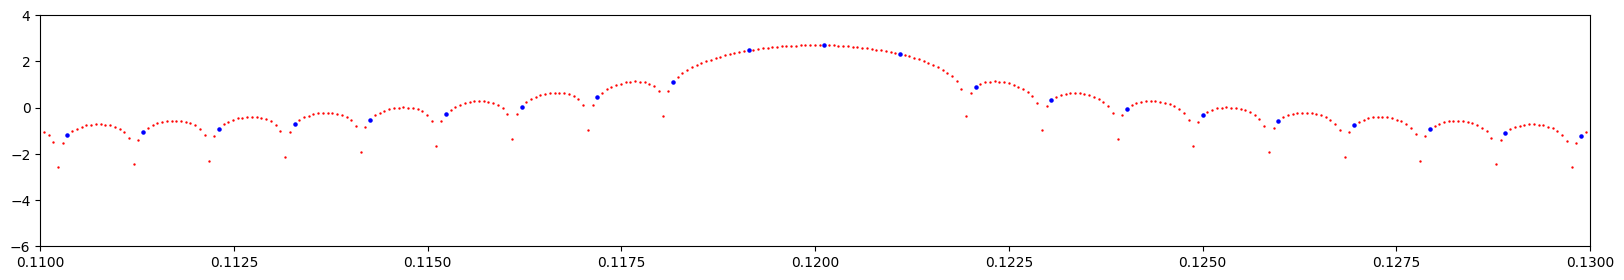

In [3]:
# Set parameters (64 signals with length 1024)

size, length = 64, 1024

# Set window

w = Window.from_cosine(length, order=1.0, dtype=dtype, device=device)
print(w)

# Set TbT data (64 signals with two components and different amplitudes)

t = torch.linspace(1.0, length, length, dtype=dtype, device=device)
data = torch.stack([i*torch.sin(2.0*numpy.pi*1*0.12*t) + 0.01*i*torch.sin(2.0*numpy.pi*2*0.12*t) for i in range(1, size + 1)])
d = Data.from_data(w, data)
print(d)

# If pad == 0, it is set to signal length
# Spectrum is computed using torch.fft.rfft(..., n=pad)/torch.fft.fft(..., n=pad) for real/complex input
# Padding can be used to interpolate DTFT spectrum in all frequency range
# This improves frequency estimation accuracy (assuming frequency corresponds to max of the largest FFT spectrum amplitude peak)
# Can be used to obtain a better initial guess, if signal has several frequencies with close amplitudes

# Initialize Frequency instances with and without padding

f1 = Frequency(d, pad=length*2**4)
f2 = Frequency(d, pad=length*2**0)
print(f1)
print(f2)

# Apply window (note, window is applied to work)

d.window_remove_mean()
d.window_apply()

# Compute FFT amplitude spectrum

f1.fft_get_spectrum()
f2.fft_get_spectrum()

# Reset TbT work

f1.data.reset()
f2.data.reset()


# Plot (log10) FFT spectrum for given signal id

idx = 0
plt.figure(figsize=(20, 3))
plt.scatter(f1.fft_grid.cpu().numpy(), torch.log10(f1.fft_spectrum[idx]).cpu().numpy(), s=0.5, c='red')
plt.scatter(f2.fft_grid.cpu().numpy(), torch.log10(f2.fft_spectrum[idx]).cpu().numpy(), s=5.0, c='blue')
plt.xlim(0.12 - 0.01, 0.12 + 0.01)
plt.ylim(-6.0, 4.0)
plt.show()

# Clean

del w
del t, data
del d
del f1, f2
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()